In [4]:
import os
from dotenv import load_dotenv

load_dotenv()

True

In [5]:
# custom tools


def add(a: int, b: int) -> int:
    """Add a and b
    Args:
        a(int): first int
        b(int): second int

        returns:
        int
    """
    return a + b


def multiply(a: int, b: int) -> int:
    """Multiply a and b
    Args:
        a(int): first int
        b(int): second int

        returns:
        int
    """
    return a * b


def divide(a: int, b: int) -> int:
    """divide a and b
    Args:
        a(int): first int
        b(int): second int

        returns:
        int
    """
    return a / b

tools = [add, multiply, divide]

In [6]:
# bind llm with tools and test
from langchain_groq import ChatGroq
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

llm = ChatGroq(model="qwen/qwen3-32b")

llm_with_tools = llm.bind_tools(tools)

tool_call = llm_with_tools.invoke(
    [HumanMessage(content=f"what is 2 plus 2")]
)
print(tool_call) # the output is from tools and not ai
print(tool_call.tool_calls)

content='' additional_kwargs={'reasoning_content': 'Okay, the user is asking "what is 2 plus 2". Let me see which tool to use here. The available functions are add, multiply, and divide. The question is about addition, so the add function is the right choice. The parameters needed are a and b, both integers. Here, a is 2 and b is 2. So I should call the add function with these values. I need to make sure the JSON structure is correct, with the name as "add" and the arguments as a JSON object with a and b. Let me double-check the function signature to confirm. Yep, that\'s right. No other functions are needed here. Alright, time to format the tool call correctly.\n', 'tool_calls': [{'id': '83kdk8kvm', 'function': {'arguments': '{"a":2,"b":2}', 'name': 'add'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 176, 'prompt_tokens': 361, 'total_tokens': 537, 'completion_time': 0.279181081, 'completion_tokens_details': {'reasoning_tokens': 147}, 'prompt_time': 0.

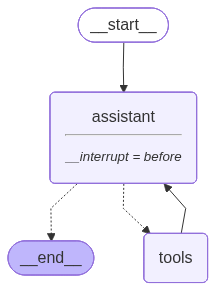

In [7]:
## create Graph

# configure the graph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph import MessagesState  # inbuilt langgraph state for messages
from langgraph.checkpoint.memory import InMemorySaver

# system message
sys_msg = SystemMessage(
    content="You are a helpful assistant tasked with performing arithmatic operation on a set of inputs"
)


# creating a assistant node
def assistant(state: MessagesState):
    return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}


builder = StateGraph(MessagesState)

builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # if the latest message from LLM is a toolcall -> tools_condition route to tools
    # if the latest message from LLM is not a toolcall -> tools_condition route to END
    tools_condition,
)
builder.add_edge("tools", "assistant")

memory = InMemorySaver()

graph = builder.compile(interrupt_before=["assistant"], checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
config = {"configurable": {"thread_id": "123"}}
initial_input = {"messages": HumanMessage(content="What is 5 plus 5")}

for message in graph.stream(initial_input, config, stream_mode="values"):
    message["messages"][-1].pretty_print()


================================ Human Message =================================

What is 5 plus 5


In [9]:
# to know the state of the current graph
state=graph.get_state(config)
print(state) # current state
print(state.next) # next state

StateSnapshot(values={'messages': [HumanMessage(content='What is 5 plus 5', additional_kwargs={}, response_metadata={}, id='4a78ce87-7468-4b89-a629-937b37219747')]}, next=('assistant',), config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f1496ff-65c7-6b27-8000-ae6ce3eae5f4'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-05-06T17:21:04.864951+00:00', parent_config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f1496ff-65c5-6416-bfff-47e12eeb195c'}}, tasks=(PregelTask(id='b177f092-6c3d-6f0d-c944-99cd83deb83b', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result=None),), interrupts=())
('assistant',)


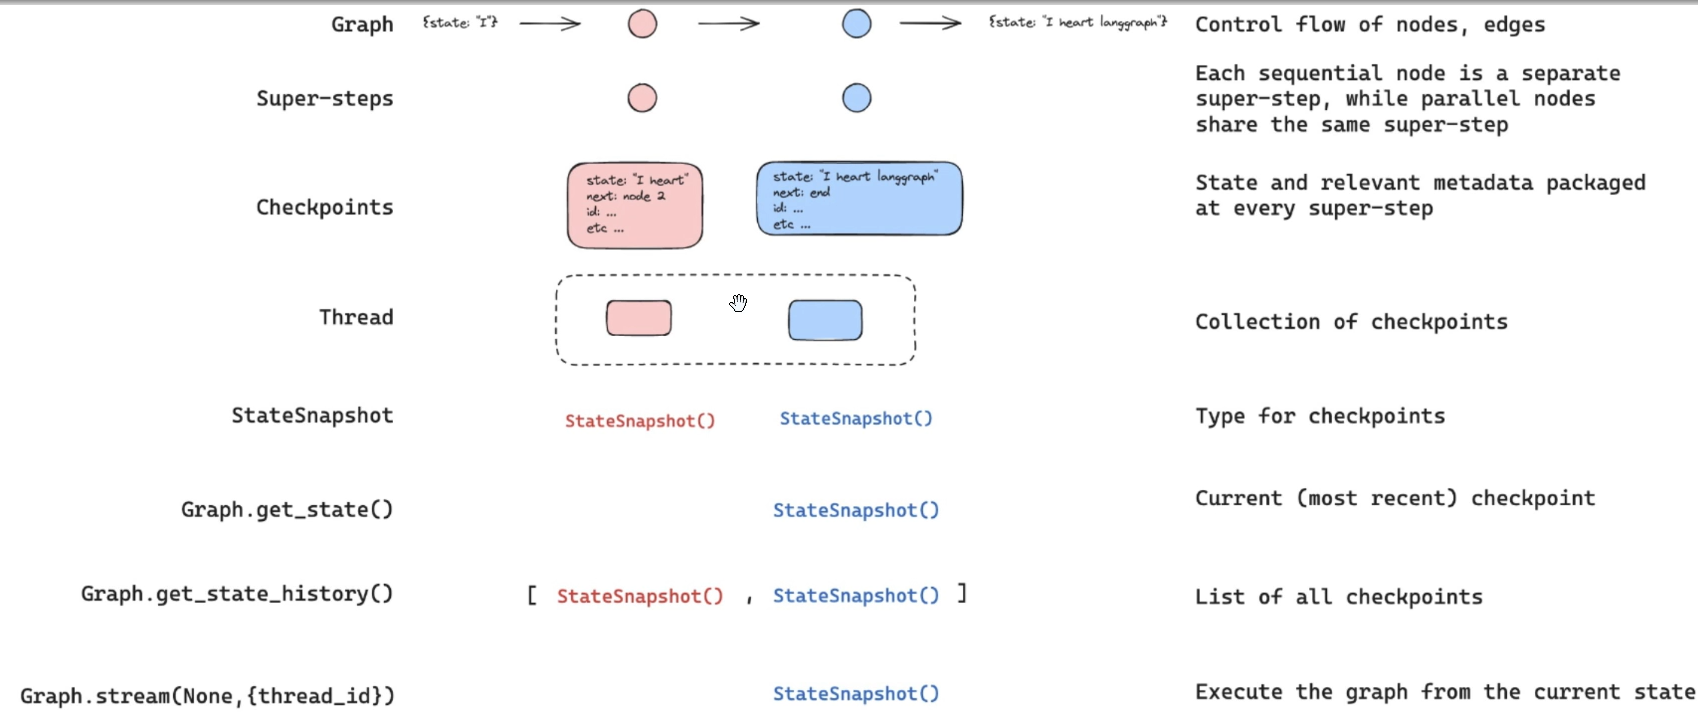

In [10]:
# execute graph from the current state

for message in graph.stream(None, config, stream_mode="values"):
    message["messages"][-1].pretty_print()

================================ Human Message =================================

What is 5 plus 5
================================== Ai Message ==================================
Tool Calls:
  add (eqpnphw7p)
 Call ID: eqpnphw7p
  Args:
    a: 5
    b: 5
================================= Tool Message =================================
Name: add

10


In [11]:
# to check the state of the current graph
state=graph.get_state(config)
print(state) # current state
print(state.next) # next state

StateSnapshot(values={'messages': [HumanMessage(content='What is 5 plus 5', additional_kwargs={}, response_metadata={}, id='4a78ce87-7468-4b89-a629-937b37219747'), AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, let\'s see. The user is asking "What is 5 plus 5". I need to figure out which function to use here. The available functions are add, multiply, and divide. The question uses the word "plus", which clearly indicates addition. So the add function is the right choice. The parameters are 5 and 5. I\'ll call the add function with a=5 and b=5. No need to consider other functions since the operation is straightforward. The answer should be 10.\n', 'tool_calls': [{'id': 'eqpnphw7p', 'function': {'arguments': '{"a":5,"b":5}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 136, 'prompt_tokens': 379, 'total_tokens': 515, 'completion_time': 0.263912313, 'completion_tokens_details': {'reasoning_tokens': 107}, 'prompt_time':

In [12]:
# execute the next step after tool gives provides llm with the answer
for message in graph.stream(None, config, stream_mode="values"):
    message["messages"][-1].pretty_print()

================================= Tool Message =================================
Name: add

10
================================== Ai Message ==================================

The result of 5 plus 5 is **10**.


#### Edit Human Feedback

In [13]:
config = {"configurable": {"thread_id": "321"}}
initial_input = {"messages": HumanMessage(content="What is 5 plus 5")}

for message in graph.stream(initial_input, config, stream_mode="values"):
    message["messages"][-1].pretty_print()

================================ Human Message =================================

What is 5 plus 5


In [14]:
# checking the state of the current graph
state=graph.get_state(config)
print(state) # current state
print(state.next) # next state

StateSnapshot(values={'messages': [HumanMessage(content='What is 5 plus 5', additional_kwargs={}, response_metadata={}, id='bfdc5cfc-8118-44cf-9877-e6aa26f6c5b2')]}, next=('assistant',), config={'configurable': {'thread_id': '321', 'checkpoint_ns': '', 'checkpoint_id': '1f149700-0309-63ee-8000-d1a09e9327a1'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-05-06T17:21:21.354442+00:00', parent_config={'configurable': {'thread_id': '321', 'checkpoint_ns': '', 'checkpoint_id': '1f149700-0309-63ed-bfff-bfd9034e40f3'}}, tasks=(PregelTask(id='4b84403b-5c88-37b1-656f-38cf93857e93', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result=None),), interrupts=())
('assistant',)


In [ ]:
# updating the state of the graph with new input
graph.update_state(config, {"messages": [HumanMessage(content="What is 10 minus 3")]})

{'configurable': {'thread_id': '321',
  'checkpoint_ns': '',
  'checkpoint_id': '1f149719-45d8-685f-8001-9fe22107f07f'}}

In [19]:
# checking the new state of the current graph
new_state=graph.get_state(config).values
for m in new_state['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 plus 5
================================ Human Message =================================

What is 10 minus 3


In [20]:
for message in graph.stream(None, config, stream_mode="values"):
    message["messages"][-1].pretty_print()

================================ Human Message =================================

What is 10 minus 3
================================== Ai Message ==================================
Tool Calls:
  add (st5xhgscv)
 Call ID: st5xhgscv
  Args:
    a: 10
    b: -3
================================= Tool Message =================================
Name: add

7


In [21]:
for message in graph.stream(None, config, stream_mode="values"):
    message["messages"][-1].pretty_print()

================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================

The result of 10 minus 3 is $\boxed{7}$.
